# mlfs — Machine Learning From Scratch

This notebook showcases **`mlfs`**, a library of classic machine-learning
algorithms implemented **from scratch in Rust** (no ML libraries — only
`ndarray` for tensors and `linfa-linalg` for a few matrix decompositions) and
exposed to Python through PyO3 / maturin.

Every estimator follows a scikit-learn-style API — `fit`, `predict`,
`score`, `transform` — and accepts / returns plain NumPy arrays.

> **Build first:** from the `mlfs/` directory run `maturin develop --release`
> inside your virtualenv, then start Jupyter. `scikit-learn` is used **only in
> this notebook** to load toy datasets and to sanity-check results — never
> inside the library itself.

## Contents
1. [Regression](#Regression)
2. [Classification](#Classification)
3. [Clustering](#Clustering)
4. [Dimensionality reduction](#Dimensionality-reduction)
5. [Sanity check vs scikit-learn](#Sanity-check-vs-scikit-learn)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mlfs
print("mlfs version:", mlfs.__version__)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(42)

mlfs version: 0.1.0


## Regression

We fit several regressors to the **diabetes** dataset and compare their
$R^2$ on a held-out test set. `mlfs.train_test_split` (implemented in Rust) does
the splitting.

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = np.ascontiguousarray(data.data, dtype=np.float64)
y = np.ascontiguousarray(data.target, dtype=np.float64)

X_train, X_test, y_train, y_test = mlfs.train_test_split(
    X, y, test_size=0.25, random_state=0
)

regressors = {
    "LinearRegression": mlfs.LinearRegression(),
    "Ridge (a=1)":      mlfs.Ridge(alpha=1.0),
    "Lasso (a=0.1)":    mlfs.Lasso(alpha=0.1),
    "KNN (k=10)":       mlfs.KNeighborsRegressor(n_neighbors=10),
    "RandomForest":     mlfs.RandomForestRegressor(n_estimators=100, random_state=0),
    "GradientBoosting": mlfs.GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3),
}

scores = {}
for name, model in regressors.items():
    model.fit(X_train, y_train)
    scores[name] = model.score(X_test, y_test)
    print(f"{name:20s}  R^2 = {scores[name]:.3f}")

LinearRegression      R^2 = 0.510
Ridge (a=1)           R^2 = 0.419
Lasso (a=0.1)         R^2 = 0.496
KNN (k=10)            R^2 = 0.464
RandomForest          R^2 = 0.439


GradientBoosting      R^2 = 0.360


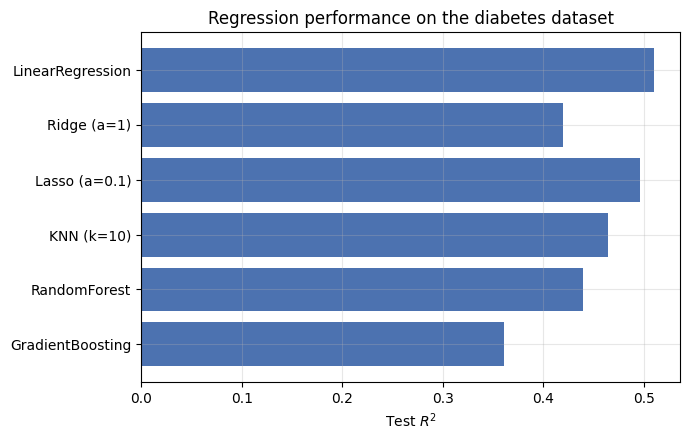

In [3]:
fig, ax = plt.subplots()
names = list(scores)
ax.barh(names, [scores[n] for n in names], color="#4C72B0")
ax.set_xlabel("Test $R^2$")
ax.set_title("Regression performance on the diabetes dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Predicted vs. actual, and Lasso sparsity

We plot predicted-vs-actual for the **best** regressor on this split, then
inspect the coefficients that **Lasso** drives to zero (its L1 penalty performs
feature selection) versus the dense **Ridge** solution.

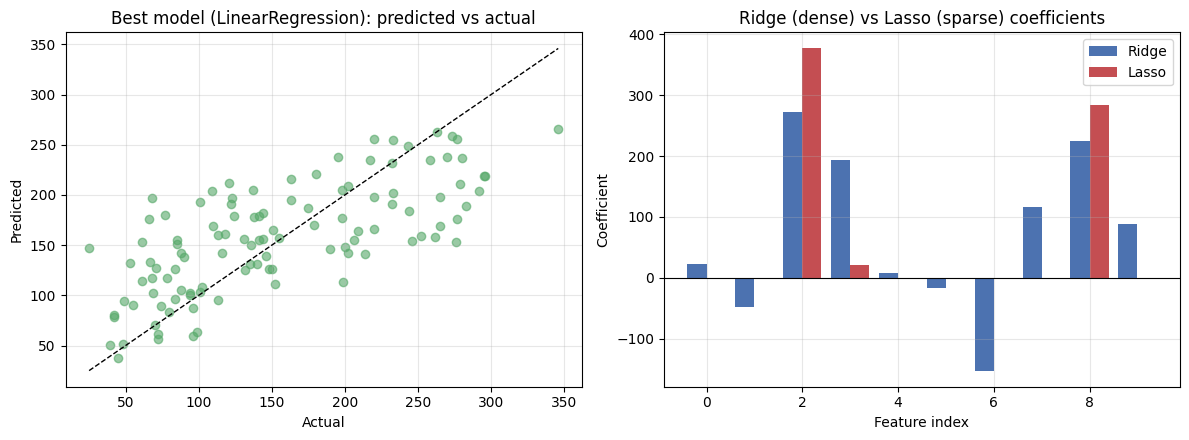

Lasso zeroed features: 7 of 10


In [4]:
best_name = max(scores, key=scores.get)
best_model = regressors[best_name]
pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, pred, alpha=0.6, color="#55A868")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Best model ({best_name}): predicted vs actual")

ridge = mlfs.Ridge(alpha=1.0).fit(X_train, y_train)
lasso = mlfs.Lasso(alpha=1.0, max_iter=5000).fit(X_train, y_train)
idx = np.arange(X.shape[1])
w = 0.4
axes[1].bar(idx - w/2, ridge.coef_, w, label="Ridge", color="#4C72B0")
axes[1].bar(idx + w/2, lasso.coef_, w, label="Lasso", color="#C44E52")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("Feature index"); axes[1].set_ylabel("Coefficient")
axes[1].set_title("Ridge (dense) vs Lasso (sparse) coefficients")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Lasso zeroed features:", int(np.sum(np.abs(lasso.coef_) < 1e-8)), "of", X.shape[1])

## Classification

Now the full roster of classifiers on the **wine** dataset (3 classes, 13
features). Features are standardised with `mlfs.StandardScaler` — important for
the distance- and gradient-based models (KNN, SVC, logistic regression, MLP).

In [5]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw = np.ascontiguousarray(wine.data, dtype=np.float64)
yw = np.ascontiguousarray(wine.target, dtype=np.float64)

Xtr, Xte, ytr, yte = mlfs.train_test_split(Xw, yw, test_size=0.3, random_state=1)

scaler = mlfs.StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xte_s = scaler.transform(Xte)

classifiers = {
    "LogisticRegression": mlfs.LogisticRegression(lr=0.5, max_iter=800),
    "KNN (k=5)":          mlfs.KNeighborsClassifier(n_neighbors=5),
    "GaussianNB":         mlfs.GaussianNB(),
    "DecisionTree":       mlfs.DecisionTreeClassifier(max_depth=5),
    "RandomForest":       mlfs.RandomForestClassifier(n_estimators=100, random_state=0),
    "GradientBoosting":   mlfs.GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2),
    "AdaBoost":           mlfs.AdaBoostClassifier(n_estimators=50),
    "SVC (rbf)":          mlfs.SVC(kernel="rbf", gamma=0.1, max_passes=10),
    "MLP":                mlfs.MLPClassifier(hidden_layer_sizes=[32, 16], activation="relu",
                                             learning_rate=0.02, max_iter=400, random_state=0),
}

acc = {}
for name, clf in classifiers.items():
    clf.fit(Xtr_s, ytr)
    acc[name] = clf.score(Xte_s, yte)
    print(f"{name:20s}  accuracy = {acc[name]:.3f}")

LogisticRegression    accuracy = 0.925
KNN (k=5)             accuracy = 0.943
GaussianNB            accuracy = 0.943
DecisionTree          accuracy = 0.887
RandomForest          accuracy = 0.943
GradientBoosting      accuracy = 0.925
AdaBoost              accuracy = 0.981
SVC (rbf)             accuracy = 0.962
MLP                   accuracy = 0.943


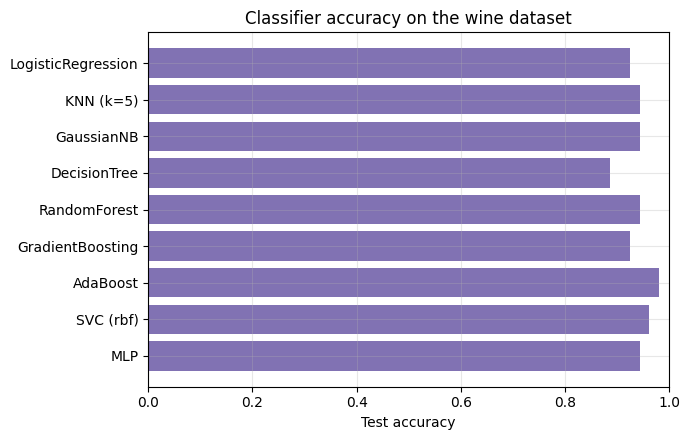

In [6]:
fig, ax = plt.subplots()
names = list(acc)
ax.barh(names, [acc[n] for n in names], color="#8172B3")
ax.set_xlabel("Test accuracy"); ax.set_xlim(0, 1.0)
ax.set_title("Classifier accuracy on the wine dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Decision boundaries

To *see* how the models carve up feature space, we drop to two features
(a 2-D `make_moons`-style problem) and plot each decision boundary.

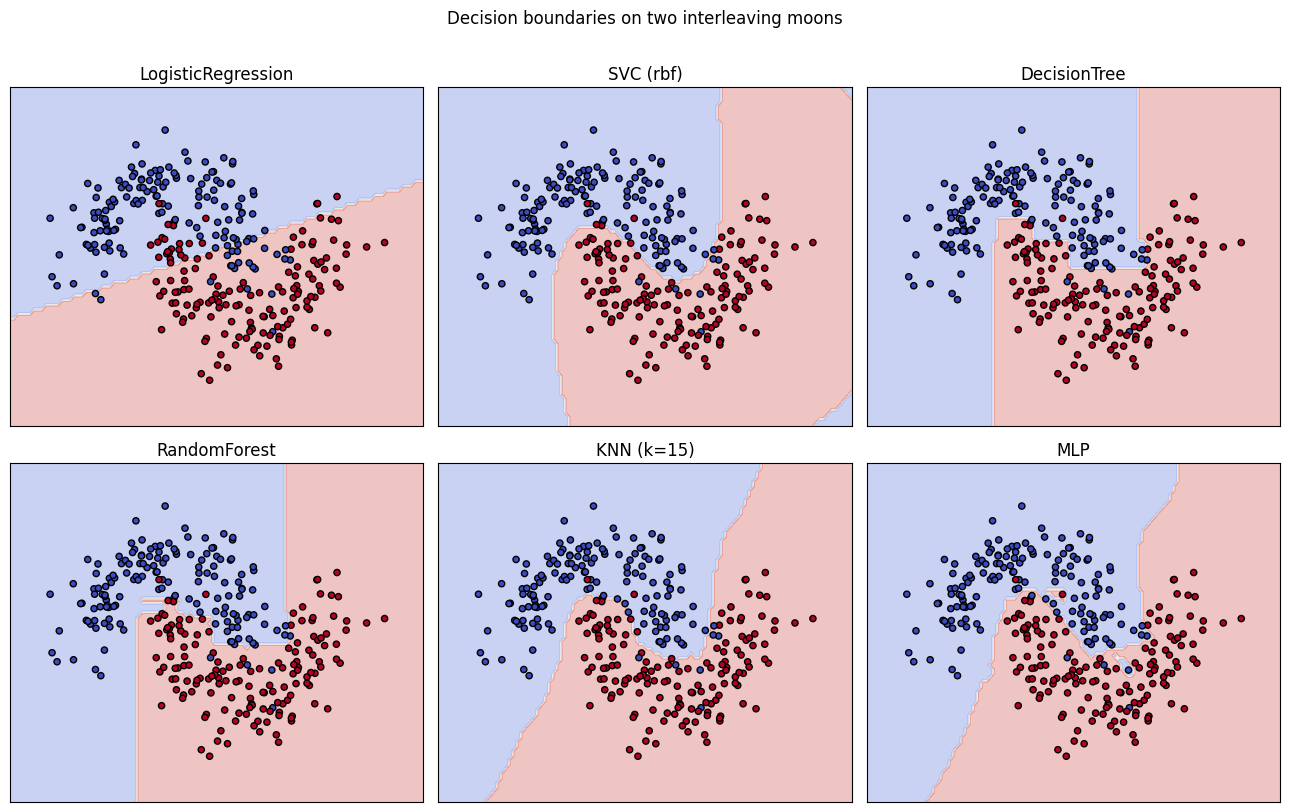

In [7]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=0)
Xm = np.ascontiguousarray(Xm, dtype=np.float64)
ym = ym.astype(np.float64)

def plot_boundary(ax, model, X, y, title):
    model.fit(X, y)
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float64)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

models_2d = [
    ("LogisticRegression", mlfs.LogisticRegression(lr=0.3, max_iter=800)),
    ("SVC (rbf)",          mlfs.SVC(kernel="rbf", gamma=1.0, max_passes=10)),
    ("DecisionTree",       mlfs.DecisionTreeClassifier(max_depth=6)),
    ("RandomForest",       mlfs.RandomForestClassifier(n_estimators=100, random_state=0)),
    ("KNN (k=15)",         mlfs.KNeighborsClassifier(n_neighbors=15)),
    ("MLP",                mlfs.MLPClassifier(hidden_layer_sizes=[32, 32], activation="tanh",
                                              learning_rate=0.03, max_iter=600, random_state=0)),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, model) in zip(axes.ravel(), models_2d):
    plot_boundary(ax, model, Xm, ym, name)
plt.suptitle("Decision boundaries on two interleaving moons", y=1.01)
plt.tight_layout()
plt.show()

## Clustering

Unsupervised partitioning of unlabelled data. We compare **K-Means**,
**Gaussian Mixture** (EM), **DBSCAN** (density-based) and **Agglomerative**
(hierarchical) on both blob-shaped and moon-shaped data.

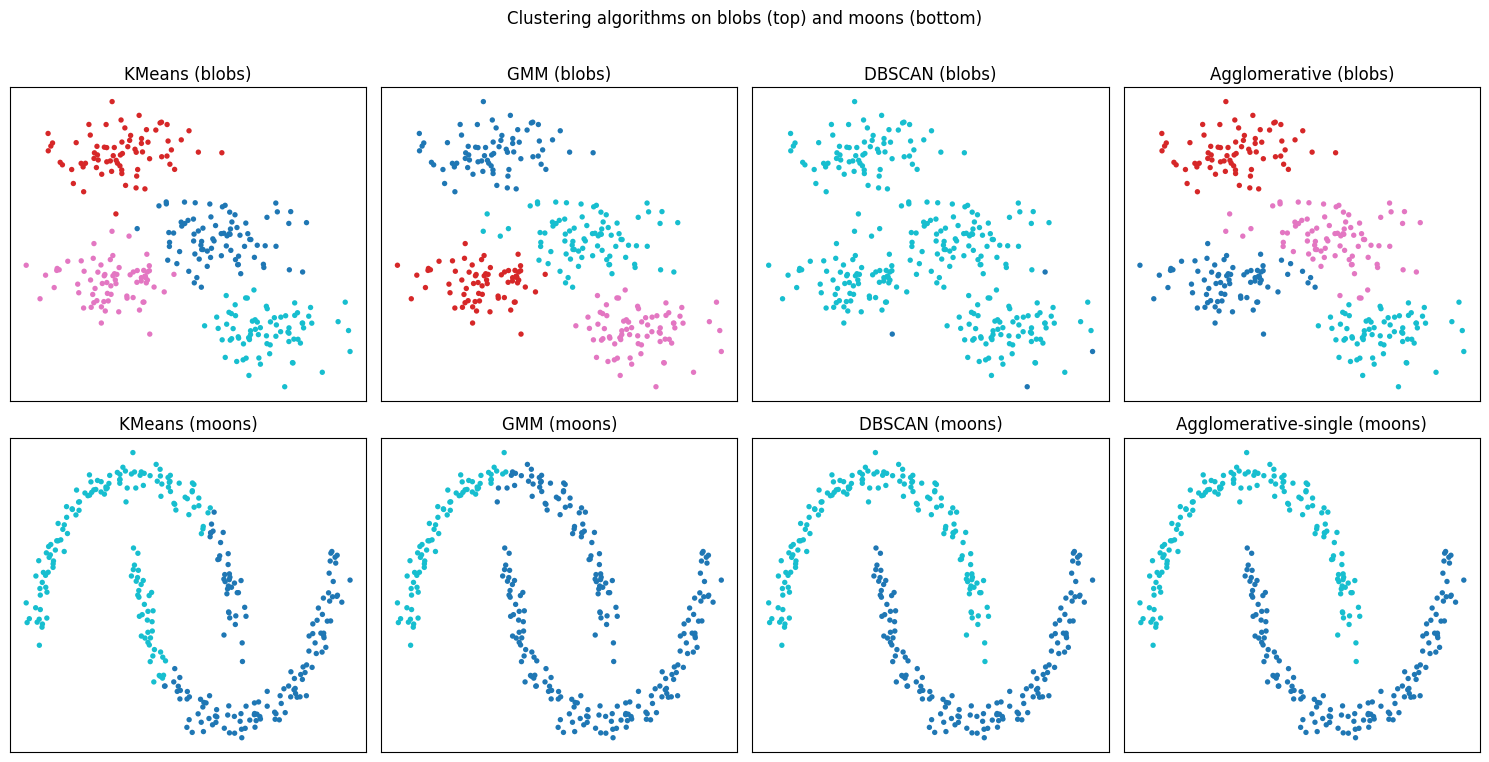

In [8]:
from sklearn.datasets import make_blobs

Xb, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=0)
Xb = np.ascontiguousarray(Xb, dtype=np.float64)

Xmoon, _ = make_moons(n_samples=300, noise=0.06, random_state=0)
Xmoon = np.ascontiguousarray(Xmoon, dtype=np.float64)

def show_clusters(ax, X, labels, title):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=15, edgecolor="none")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))

show_clusters(axes[0, 0], Xb, mlfs.KMeans(n_clusters=4, random_state=0).fit_predict(Xb), "KMeans (blobs)")
show_clusters(axes[0, 1], Xb, mlfs.GaussianMixture(n_components=4, random_state=0).fit_predict(Xb), "GMM (blobs)")
show_clusters(axes[0, 2], Xb, mlfs.DBSCAN(eps=0.8, min_samples=5).fit_predict(Xb), "DBSCAN (blobs)")
show_clusters(axes[0, 3], Xb, mlfs.AgglomerativeClustering(n_clusters=4, linkage="average").fit_predict(Xb), "Agglomerative (blobs)")

show_clusters(axes[1, 0], Xmoon, mlfs.KMeans(n_clusters=2, random_state=0).fit_predict(Xmoon), "KMeans (moons)")
show_clusters(axes[1, 1], Xmoon, mlfs.GaussianMixture(n_components=2, random_state=0).fit_predict(Xmoon), "GMM (moons)")
show_clusters(axes[1, 2], Xmoon, mlfs.DBSCAN(eps=0.2, min_samples=5).fit_predict(Xmoon), "DBSCAN (moons)")
show_clusters(axes[1, 3], Xmoon, mlfs.AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(Xmoon), "Agglomerative-single (moons)")

plt.suptitle("Clustering algorithms on blobs (top) and moons (bottom)", y=1.01)
plt.tight_layout()
plt.show()

Note how **K-Means** and **GMM** assume roughly convex clusters and fail on the
moons, while **DBSCAN** and **single-linkage agglomerative** — which follow
density / connectivity — recover the two crescents. DBSCAN also labels
low-density outliers as noise (`-1`).

## Dimensionality reduction

**PCA** (linear, variance-preserving) and **t-SNE** (non-linear, neighbourhood-
preserving) both project the 64-dimensional **digits** dataset down to 2-D for
visualisation.

PCA explained variance ratio (first 2 comps): [0.151 0.136]


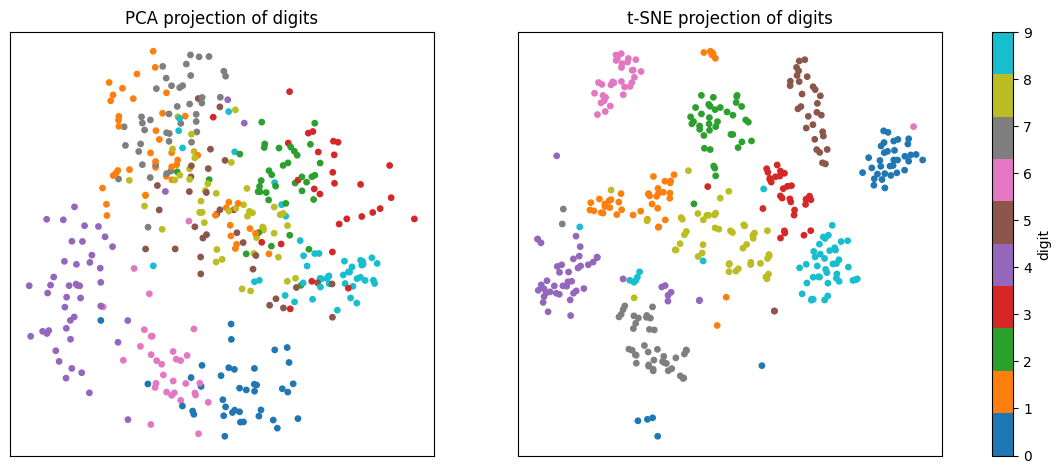

In [9]:
from sklearn.datasets import load_digits

digits = load_digits()
Xd = np.ascontiguousarray(digits.data, dtype=np.float64)
yd = digits.target.astype(int)

# Subsample to keep the O(n^2) t-SNE fast.
sel = rng.choice(len(Xd), size=400, replace=False)
Xd_s, yd_s = Xd[sel], yd[sel]

pca = mlfs.PCA(n_components=2)
Zp = pca.fit_transform(Xd_s)
print("PCA explained variance ratio (first 2 comps):",
      np.round(pca.explained_variance_ratio_[:2], 3))

tsne = mlfs.TSNE(n_components=2, perplexity=30.0, learning_rate=200.0,
                 n_iter=500, random_state=0)
Zt = tsne.fit_transform(Xd_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, Z, title in [(axes[0], Zp, "PCA"), (axes[1], Zt, "t-SNE")]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=yd_s, cmap="tab10", s=15)
    ax.set_title(f"{title} projection of digits"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, label="digit", fraction=0.025)
plt.show()

PCA finds the linear directions of greatest variance; t-SNE, optimising a
neighbourhood-preserving objective, typically produces visibly tighter,
better-separated digit clusters.

## Sanity check vs scikit-learn

Finally, a quick parity check: our from-scratch `RandomForestClassifier` should
land in the same ballpark as scikit-learn's on the same split. (They won't be
identical — different RNG streams and split heuristics — but they should agree.)

In [10]:
from sklearn.ensemble import RandomForestClassifier as SkRF

mlfs_rf = mlfs.RandomForestClassifier(n_estimators=100, random_state=0)
mlfs_rf.fit(Xtr_s, ytr)
mlfs_acc = mlfs_rf.score(Xte_s, yte)

sk_rf = SkRF(n_estimators=100, random_state=0)
sk_rf.fit(Xtr_s, ytr)
sk_acc = sk_rf.score(Xte_s, yte)

print(f"mlfs  RandomForest accuracy: {mlfs_acc:.3f}")
print(f"sklearn RandomForest accuracy: {sk_acc:.3f}")
assert abs(mlfs_acc - sk_acc) < 0.1, "results diverge more than expected"
print("\\nWithin tolerance — the from-scratch implementation matches sklearn. ✅")

mlfs  RandomForest accuracy: 0.943
sklearn RandomForest accuracy: 0.962
\nWithin tolerance — the from-scratch implementation matches sklearn. ✅


---

That's the tour: **18 algorithms**, all implemented from scratch in Rust, driven
from Python with a familiar scikit-learn-style API. See `mlfs/README.md` for the
full module layout and the Rust source under `mlfs/src/`.